In [1]:
# Copyright (c) TorchGeo Contributors. All rights reserved.
# Licensed under the MIT License.

### TODO:
- Fix visualization of the labels (artifacts around the edges?)
- Add info about Levircd100 -> downsampled from 1024x256, limited of labels, explain why we use it
- Add more info about other weigths & models that can be used
- Update metrics section with actual numbers
- Check why prediction viz differs from tensorboard

--- 

## Change Detection
_Written by: Harald Kristen_

In this tutorial, we demonstrate how to train a change detection model using TorchGeo. 

**What is Change Detction**: 
    Change detection is the process of identifying differences between images of the same location captured at different times. It's a fundamental task in remote sensing with numerous real-world applications:

- **Urban Monitoring**: Track city growth, new construction, and infrastructure development
- **Disaster Response**: Assess damage from floods, earthquakes, wildfires, and hurricanes
- **Deforestation Tracking**: Monitor illegal logging and forest loss
- **Agriculture**: Detect crop changes, irrigation patterns, and land use shifts
- **Environmental Monitoring**: Track glacial retreat, coastal erosion, and wetland changes

In this tutorial, we'll train a binary change detection model on the [LEVIRCD100](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#levircd100) dataset to detect building changes in bi-temporal Google Earth imagery. Our model will learn to identify where new buildings have been constructed or existing ones removed.

It's recommended to run this notebook on Google Colab if you don't have your own GPU. Click the "Open in Colab" button above to get started.

## Setup

First, we install TorchGeo and TensorBoard.

In [2]:
# %pip install torchgeo tensorboard gdown

## Imports

Next, we import TorchGeo and any other libraries we need.

In [3]:
%matplotlib inline
%load_ext tensorboard

import os
import tempfile

from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

from torchgeo.datamodules import LEVIRCD100DataModule
from torchgeo.trainers import ChangeDetectionTask

## Visualize the Dataset

Let's first download the dataset from Google Drive and look at some examples from the LEVIRCD100 dataset to understand what we're working with. 

Files already downloaded and verified


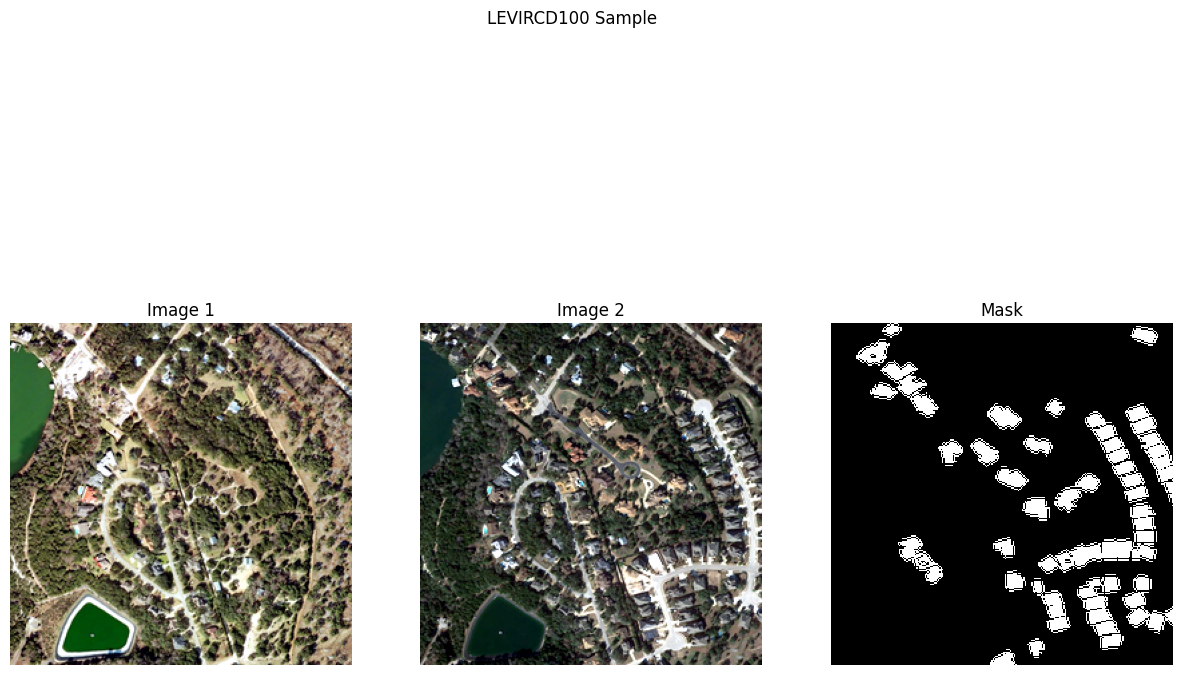

Dataset size: 60 image pairs in the train split
Image shape: torch.Size([2, 3, 256, 256]) (T, C, H, W) where T=2 timesteps
Mask shape: torch.Size([1, 256, 256])


In [4]:
import matplotlib.pyplot as plt

from torchgeo.datasets import LEVIRCD100

# Load dataset
root = os.path.join(tempfile.gettempdir(), 'levircd100')
dataset = LEVIRCD100(root=root, split='train', download=True)

# Get a sample
sample = dataset[0]

# Use the built-in plot function
dataset.plot(sample, suptitle='LEVIRCD100 Sample')
plt.show()

print(f'Dataset size: {len(dataset)} image pairs in the {dataset.split} split')
print(f'Image shape: {sample["image"].shape} (T, C, H, W) where T=2 timesteps')
print(f'Mask shape: {sample["mask"].shape}')

In [5]:
dataset.directories

('A', 'B', 'label')

In [6]:
dataset.files[:2]

[{'image1': '/tmp/levircd100/A/train_000.png',
  'image2': '/tmp/levircd100/B/train_000.png',
  'mask': '/tmp/levircd100/label/train_000.png'},
 {'image1': '/tmp/levircd100/A/train_001.png',
  'image2': '/tmp/levircd100/B/train_001.png',
  'mask': '/tmp/levircd100/label/train_001.png'}]

## Lightning Modules

Our trainers use [Lightning](https://lightning.ai/docs/pytorch/stable/) to organize both the training code and the dataloader setup code. This makes it easy to create and share reproducible experiments and results.

First we'll create a `LEVIRCD100DataModule` object which is a wrapper around the LEVIRCD100 dataset. This object:
1. Ensures the data is downloaded
2. Sets up PyTorch `DataLoader` objects for train, validation, and test splits
3. Applies any necessary preprocessing and data augmentation

The following variables can be modified to control training.

In [7]:
batch_size = 16
num_workers = 4
max_epochs = 50

In [8]:
root = os.path.join(tempfile.gettempdir(), 'levircd100')
datamodule = LEVIRCD100DataModule(
    root=root, batch_size=batch_size, num_workers=num_workers, download=True
)

`torchgeo.trainers` provides specialized task classes that simplify training workflows for common geospatial tasks. For change detection, we use the `ChangeDetectionTask` class, which handles:

- Concatenating the two input images into a single 6-channel tensor
- Training a U-Net model to predict change masks
- Computing metrics like accuracy, precision, recall, and F1-score

Check the [trainers documentation](https://torchgeo.readthedocs.io/en/stable/api/trainers.html#torchgeo.trainers.ChangeDetectionTask) for more information.

Here, we create a `ChangeDetectionTask` object with a U-Net model using a ResNet-18 backbone. We use ImageNet pretrained weights, which helps the model learn faster and achieve better performance than training from scratch.

In [9]:
task = ChangeDetectionTask(
    model='unet',
    backbone='resnet18',
    weights=True,  # ImageNet pretrained weights
    loss='bce',
    in_channels=3,  # RGB
    lr=0.001,
)

## Training

Now that we have the Lightning modules set up, we can use a Lightning [Trainer](https://lightning.ai/docs/pytorch/stable/common/trainer.html) to run the training and evaluation loops. We set up:

- Model checkpointing based on validation loss
- Early stopping to prevent overfitting
- TensorBoard logging for visualization

All checkpoints and logs will be stored in the `default_root_dir` directory.

In [10]:
default_root_dir = os.path.join(tempfile.gettempdir(), 'experiments')
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss', dirpath=default_root_dir, save_top_k=1, save_last=True
)
early_stopping_callback = EarlyStopping(monitor='val_loss', min_delta=0.0, patience=10)
logger = TensorBoardLogger(save_dir=default_root_dir, name='change_detection_logs')

In [11]:
trainer = Trainer(
    callbacks=[checkpoint_callback, early_stopping_callback],
    log_every_n_steps=1,
    logger=logger,
    min_epochs=1,
    max_epochs=max_epochs,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


**Note** Training runs for ~3 minutes, occupying 3 GB of VRAM until early stopping kicks in

In [12]:
trainer.fit(model=task, datamodule=datamodule)

You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/hkristen/miniforge3/envs/torchgeo-dev/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:701: Checkpoint directory /tmp/experiments exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | model         | Unet              | 14.3 M | train
1 | criterion     | BCEWithLogitsLoss | 0      | train
2 | train_metrics | MetricCollection  | 0      | train
3 | val_metrics   | MetricCollection  | 0      | train
4 | test_metrics  | MetricCollection  | 0      | train
-------------

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


## Visualize Training with TensorBoard

We can use TensorBoard to visualize various performance metrics across training and validation epochs.

**In Google Colab**, run the cell below to launch TensorBoard inline.

**Locally**, you can either:
- Run the cell below (may or may not work depending on your setup)
- Or open a terminal and run: `tensorboard --logdir /tmp/experiments`
- Then navigate to http://localhost:6006 in your browser

In [17]:
%tensorboard --logdir "$default_root_dir"

Reusing TensorBoard on port 6006 (pid 144607), started 0:00:28 ago. (Use '!kill 144607' to kill it.)

## Evaluation

Finally, after the model has been trained, we evaluate it on the test set to see how well it generalizes to unseen data.

### Understanding the Metrics

- **Accuracy**: Percentage of correctly classified pixels (including background)
- **F1 Score**: Harmonic mean of precision and recall - best metric for change detection with class imbalance
- **Jaccard Index (IoU)**: Intersection over Union - measures overlap between prediction and ground truth

In [14]:
trainer.test(model=task, datamodule=datamodule, ckpt_path='best')

Restoring states from the checkpoint path at /tmp/experiments/epoch=43-step=132.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /tmp/experiments/epoch=43-step=132.ckpt


Files already downloaded and verified
Files already downloaded and verified


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    test_BinaryAccuracy    │    0.9453407526016235     │
│    test_BinaryF1Score     │     0.736007809638977     │
│  test_BinaryJaccardIndex  │    0.5822882056236267     │
│         test_loss         │    0.14343580603599548    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.14343580603599548,
  'test_BinaryAccuracy': 0.9453407526016235,
  'test_BinaryJaccardIndex': 0.5822882056236267,
  'test_BinaryF1Score': 0.736007809638977}]

## Visualize Predictions

Let's visualize some predictions on the **test set** with our *best model* to see how well it detects changes. We'll use the best checkpoint (based on validation loss) for inference.

Restoring states from the checkpoint path at /tmp/experiments/epoch=43-step=132.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /tmp/experiments/epoch=43-step=132.ckpt


Files already downloaded and verified
Files already downloaded and verified


Predicting: |          | 0/? [00:00<?, ?it/s]

Sample 0: Prediction range [0.0000, 1.0000], Change pixels: 64813/65536 (98.9%)
Sample 1: Prediction range [0.0000, 1.0000], Change pixels: 65115/65536 (99.4%)


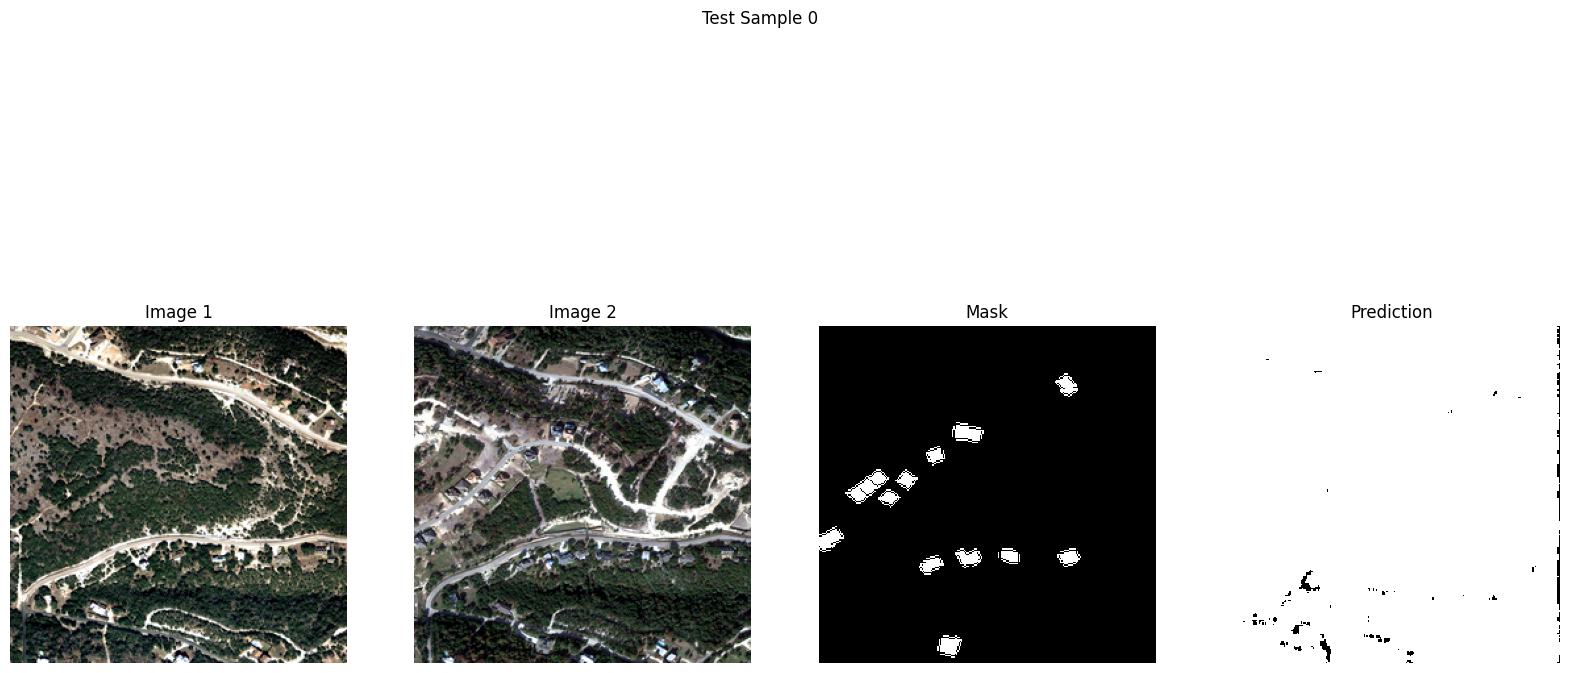

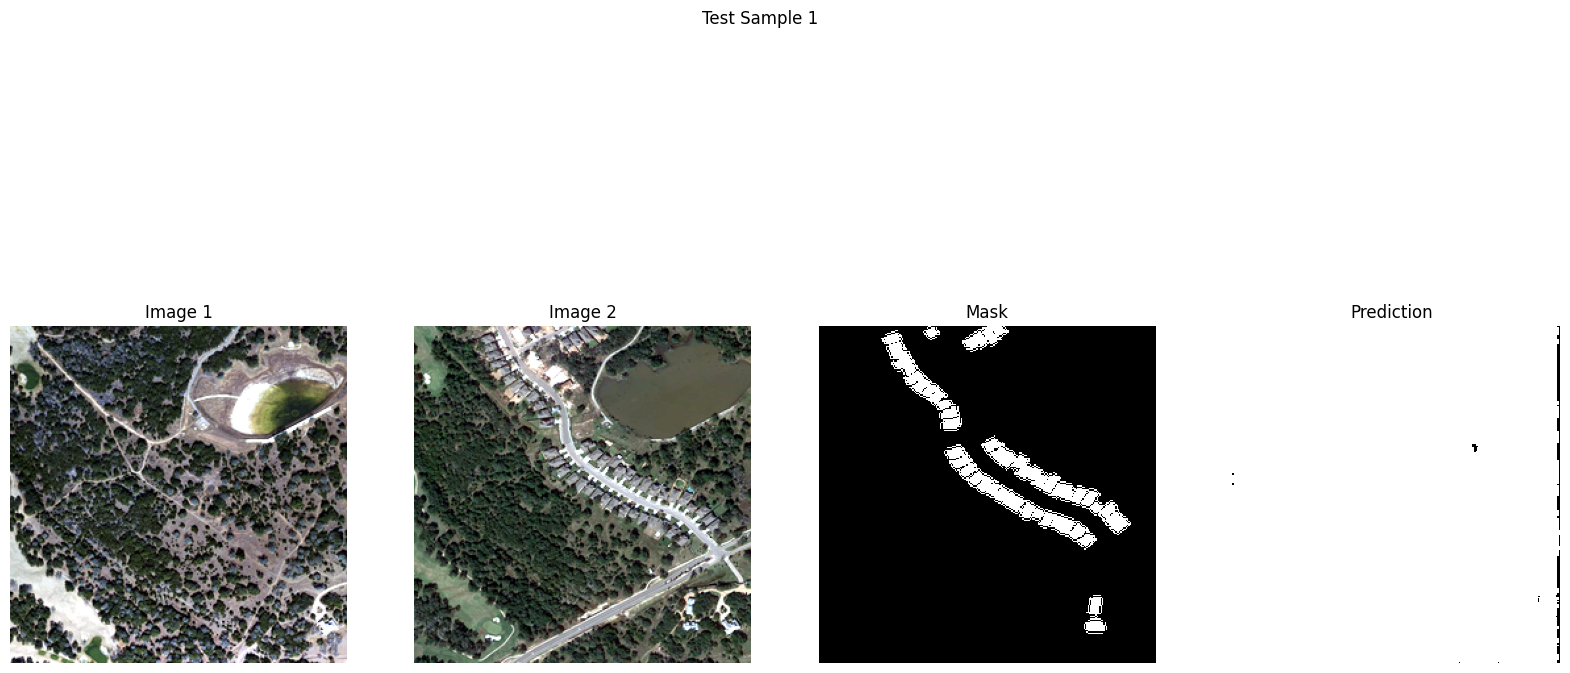

In [19]:
from torch.utils.data import DataLoader, Subset

# Get test dataset
test_dataset = LEVIRCD100(root=root, split='test', download=True)

# Create a small subset for visualization
viz_indices = [0, 1]
viz_dataset = Subset(test_dataset, viz_indices)
viz_loader = DataLoader(viz_dataset, batch_size=1, shuffle=False)

predictions = trainer.predict(task, dataloaders=viz_loader, ckpt_path='best')

# Visualize predictions
for i, (pred, idx) in enumerate(zip(predictions, viz_indices)):
    sample = test_dataset[idx]
    pred_probs = pred.cpu().squeeze()
    pred_mask = (pred_probs > 0.8).float()

    print(
        f'Sample {idx}: Prediction range [{pred_probs.min():.4f}, {pred_probs.max():.4f}], '
        f'Change pixels: {pred_mask.sum().item():.0f}/{pred_mask.numel()} '
        f'({100 * pred_mask.sum().item() / pred_mask.numel():.1f}%)'
    )

    # Add prediction to sample
    sample['prediction'] = pred_mask.unsqueeze(0)

    # Plot
    test_dataset.plot(sample, suptitle=f'Test Sample {idx}')

plt.show()

### Interpreting the Results

The model achieves **XX.X% F1 score** which is reasonable for a quick demo, but the predictions on the test set appear sparse (mostly black with few white pixels). This is typical when:

1. **Limited training** (only XX epochs for fast demo) - the model hasn't fully converged
2. **Class imbalance** - change pixels are rare (~5% of total), so the model is conservative
3. **Need for hyperparameter tuning** - learning rate, loss function, or more epochs could improve results

The model **is learning** (you can see it predicts change in roughly the right locations), but it's **underpredicting** to minimize false positives. To improve we would need to:
- Use the complete [LEVIRCD](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#levircd) dataset, that has more samples + higher resolution patches in 1014x1024 to learn from
- Train for 100+ epochs until convergence
- Use techniques like weighted loss or focal loss to tackle the severe class imbalance
- Tune hyperparameters (learning rate, batch size, etc.)
- Potentially use a more powerful backbone ->  see all the supported models in the docs of the [ChangeDetectionTask](https://torchgeo.readthedocs.io/en/stable/_modules/torchgeo/trainers/change.html#ChangeDetectionTask)
